# Lahar 2D — MK VII  (cambios del $19/09/26$)

## Objetivo de esta versión: **desbloquear el flujo**

El MK VI / Neumann estaba **frenado por fricción**: con `chi_p = 0.35` y presión de
poros *algebraica de equilibrio*, en reposo se tenía $\mu_{eff}\approx0.23$ frente a
$\tan\theta=0.08$. La fricción era **2.8× el motor gravitacional**, de modo que la única
solución admisible del sistema era $u=v=0$, $h=h_0$ para siempre.

## Cambios

### Punto 1 — Movilización
- `chi_p`: $0.35 \rightarrow 0.80$ (Iverson 1997 reporta $\lambda \approx 0.7$–$0.9$ en debris flows).
- `p_ref`: $10^4 \rightarrow 10^3$ Pa (a $h\sim1$ m, $10^4$ Pa era el 57% de $\rho g h$ y congelaba el flujo delgado).
- **Celda 7 nueva: gate físico** que verifica $\mu_{eff} < \tan\theta/\cos\theta$ en reposo **antes** de entrenar y aborta si no se cumple.
- `TOPO_SCENARIO = 4`: perfil tipo Villarrica (cono proximal empinado → valle distal), disponible pero **no** por defecto.

### Punto 2 — Presión de poros como variable de estado
- La red pasa de **4 a 5 salidas**: $(h,u,v,C,\mathbf{p})$.
- Ansatz duro: $p = \rho g h \cdot \sigma\!\left(\mathrm{logit}(\lambda_0) + \omega(t)\,p_{raw}\right)$
  → garantiza $0 < p < \rho g h$ **por construcción** y $p(t{=}0)=\lambda_0\rho g h_0$ exacto.
- EDP nueva: $\dfrac{Dp}{Dt} = \dfrac{p_{eq}(h,C,|\mathbf{u}|) - p}{\tau_p}$ (relajación, $\tau_p = 120$ s).
- `ic_p_physical` deja de ser código muerto; `tau_p` deja de ser variable no usada.

### Extra (no estaba en la lista, ver explicación)
- **Término turbulento de Voellmy** $\rho g |\mathbf{u}|^2/\xi$ añadido a $\tau_b$.
  Sin él, Coulomb puro con $\mu<\tan\theta$ **no tiene velocidad terminal** y el
  lahar aceleraría hasta $\sim60$ m/s en 100 s. Con $\xi = 500$ m/s² la velocidad
  de equilibrio queda en $\sim15$ m/s, compatible con lahares reales.
  Para recuperar Coulomb puro: `xi_voellmy = np.inf`.

## NO tocado en esta versión (puntos 3–5, pendientes)
- `kappa_C = 5.0` sigue ahí, y `loss_C_flux` (Neumann en 4 caras) también.
- Se sigue resolviendo $C$ y no $m = hC$.
- Sigue el `h = 0` tipo Dirichlet en las paredes laterales.

> Los errores de la concentración **siguen presentes por diseño**: primero hay que
> comprobar que el flujo se mueve. Con un flujo real debajo, el §2 se ataca sobre
> una base sana.


In [9]:
# ============================================================
# PINN para lahar por etapas (z_b fijo, sin Exner)
# Aprende: h, u, v, C, p   <-- p ahora SI es salida de la red
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
import matplotlib.pyplot as plt
tf.random.set_seed(7)
np.random.seed(7)


In [10]:
# ============================================================
# SELECCIÓN DE TOPOGRAFÍA
# ============================================================
# 1: plano inclinado | 2: valle parabólico 8% | 3: valle convergente
# 4: perfil tipo Villarrica (cono proximal empinado -> valle distal)
#
# Se deja el 2 por defecto A PROPÓSITO: queremos aislar el efecto de la
# presión de poros (punto 2) sobre EXACTAMENTE la misma topografía que el
# MK VI, para que la comparación de la tesis cambie una sola variable.
# El escenario 4 requiere recalibrar xi_voellmy (ver nota en la celda 3).
TOPO_SCENARIO = 2

# ============================================================
# 1) PARÁMETROS FÍSICOS
# ============================================================
g = 9.81
rho_m = 1800.0

# ---------- Reología: Coulomb con presión de poros (Iverson, 1997) ----------
#   tau_b = mu_eff * rho*g*h*cos(theta) ,   mu_eff = mu0*(1+aC*(C-C0))*exp(-ap*p/(rho*g*h+p_ref))
mu0 = 0.20
alpha_C = 1.2
alpha_p = 4.0
C0 = 0.45

# CAMBIO (punto 1): p_ref  1e4 -> 1e3 Pa.
#   p_ref regulariza el denominador (rho*g*h + p_ref) para que no explote
#   cuando h -> 0. Pero con h = 1 m se tiene rho*g*h = 1.77e4 Pa, así que
#   p_ref = 1e4 pesaba un 57% y hacía que el exponente -ap*p/(rho*g*h+p_ref)
#   se achicara artificialmente en flujo delgado => el frente (que siempre es
#   delgado) quedaba con mu_eff alto y se congelaba.
#   Con 1e3 Pa solo actúa para h < 0.1 m, que es donde físicamente SÍ queremos
#   que el lahar se detenga y deposite.
p_ref = 1.0e3

# ---------- Presión de poros: AHORA VARIABLE DE ESTADO (punto 2) ----------
# CAMBIO (punto 1): chi_p  0.35 -> 0.80
#   chi_p es la razón de presión de poros de EQUILIBRIO, lambda_eq = p_eq/(rho*g*h).
#   Con 0.35 el máximo alcanzable era lambda ~ 0.30, y el umbral de movilización
#   para 8% de pendiente es lambda >= 0.289: estábamos justo sobre el filo.
#   La literatura de debris flows/lahares reporta lambda ~ 0.7-0.9 (masa casi
#   licuada). 0.80 deja margen amplio.
chi_p = 0.80

# NUEVO (punto 2): razón de presión de poros INICIAL.
#   Un lahar del Villarrica nace de fusión rápida de nieve/hielo + removilización
#   de tefra: nace licuado. Este es el mecanismo de ARRANQUE que faltaba.
#   Ojo: con el cierre algebraico anterior, p(t=0) = 0 porque u(t=0) = 0.
lambda_0 = 0.60

# tau_p DEJA DE SER CÓDIGO MUERTO: es el tiempo de relajación de la EDP de p.
# Físicamente tau_p ~ h^2/D_p (difusión de presión de poros). 120 s es una
# estimación conservadora (corta); valores reales pueden ser mucho mayores,
# lo que haría al lahar aún MÁS móvil.
tau_p = 120.0
u_star = 1.0
C_star = 0.05

# ---------- NUEVO: término turbulento de Voellmy ----------
#   tau_b = mu_eff*rho*g*h*cos(theta)  +  rho*g*|u|^2/xi
#   Sin este término, Coulomb puro con mu_eff < tan(theta) NO tiene velocidad
#   terminal: el flujo acelera indefinidamente (u ~ 60 m/s a los 100 s, absurdo).
#   xi = 500 m/s^2 da u_eq ~ 15 m/s en pendiente 8%, compatible con lahares.
#   Para recuperar Coulomb puro: xi_voellmy = np.inf
xi_voellmy = 500.0

# Tolerancia mojado/seco [m]. Regulariza g*|u|^2/(xi*h), que diverge como 1/h
# en la zona seca. Estándar en solvers de aguas someras (1e-3 a 1e-1 m).
h_dry = 0.05

# Tiempo de rampa del ansatz de IC [s]. ANTES estaba atado a t_scale = Tmax
# (omega = 1 - exp(-5*t/Tmax)): al pasar Tmax de 100 a 1200 s la rampa saltó
# de 20 s a 240 s. Con el lahar ya desbloqueado, la red tendría que producir
# u ~ 11 m/s a los 20 s con omega = 0.08, o sea u_raw ~ 14: condicionamiento
# pésimo justo en la fase de arranque. Ahora es un tiempo FÍSICO fijo.
T_ramp = 20.0

# Tiempo dinámico característico del problema, T ~ L/U [s]. Se usa para
# adimensionalizar los residuos EN LUGAR de t_scale = Tmax. Si se usa Tmax,
# cambiar el horizonte de simulación cambia el peso relativo de las
# ecuaciones, que es un artefacto puro: la física no depende de hasta dónde
# decidiste integrar.
T_dyn = 100.0

# ---------- Transporte de concentración (SIN CAMBIOS en esta versión) ----------
# Heredado de tu edición del 15/09: kappa_C = 0 => la ecuación de C queda
# puramente HIPERBÓLICA (advección pura). Es lo correcto: el término difusivo
# era ~970x menor que la advección y aun así obligaba a imponer BC en las 4
# caras, que era lo que destruía el campo de concentración.
kappa_C = 0.0
tau_C = 1e9        # relajación casi nula para C (sin erosión/depositación)

eps_u = 1e-3
eps_h = 1e-6

# ============================================================
# 2) DOMINIO
# ============================================================
Lx = 10_000.0
Ly = 2_000.0
Tmax = 1200.0      # heredado de tu edición del 15/09
x_min, x_max = 0.0, Lx
y_min, y_max = -Ly/2, Ly/2
t_min, t_max = 0.0, Tmax

# Normalización
x_scale = Lx
y_scale = Ly/2
t_scale = Tmax
h_scale = 10.0
u_scale = 10.0
p_scale = rho_m * g * h_scale   # 1.766e5 Pa -- ahora SÍ se usa (escala del residuo de p)


In [11]:
# ============================================================
# 3) TOPOGRAFÍA FIJA z_b(x,y)
# ============================================================
def _log_cosh(z):
    """log(cosh(z)) estable numéricamente (evita overflow de cosh)."""
    az = tf.abs(z)
    return az + tf.math.log1p(tf.exp(-2.0 * az)) - tf.math.log(2.0)

def zb0_physical(x, y):
    if TOPO_SCENARIO == 1:
        # Plano inclinado (Pendiente 10%) - Usar solo para calibrar
        Sx = 0.10
        z0 = 3000.0
        return z0 - Sx * x

    elif TOPO_SCENARIO == 2:
        # Valle Parabólico Suave (Aproximación Villarrica / Quebrada)
        Sx = 0.08         # Pendiente longitudinal (8%)
        z0 = 2900.0       # Altitud base
        k_y = 50.0 / (1000.0**2)
        return (z0 - Sx * x) + k_y * (y**2)

    elif TOPO_SCENARIO == 3:
        # Valle Convergente (Embudamiento)
        Sx = 0.08
        z0 = 2900.0
        k_y = (20.0 + 0.01 * x) / (1000.0**2)
        return (z0 - Sx * x) + k_y * (y**2)

    else:
        # ------------------------------------------------------------
        # NUEVO (punto 1): perfil longitudinal tipo Villarrica.
        # Cono proximal empinado -> ruptura de pendiente -> valle distal.
        #   S(x) = S_dist + (S_prox - S_dist) * 0.5 * (1 - tanh((x-xb)/w))
        # integrado analíticamente para dar z(x).
        #
        # AVISO: con S_prox = 0.30 el motor gravitacional es ~4x mayor que en
        # el escenario 2, por lo que xi_voellmy DEBE recalibrarse (probar
        # xi ~ 100-200) o la velocidad de equilibrio saldrá ~40 m/s.
        # ------------------------------------------------------------
        z0 = 2847.0        # cumbre del Villarrica [m s.n.m.]
        S_prox = 0.30      # ~17 deg en el cono
        S_dist = 0.08      # ~4.6 deg en el valle distal
        x_break = 3500.0   # pie del cono
        w_break = 800.0    # ancho de la transición

        zx = tf.zeros_like(x) + x
        arg  = (zx - x_break) / w_break
        arg0 = tf.constant(-x_break / w_break, dtype=tf.float32)
        integral = (zx - w_break * _log_cosh(arg)) - (0.0 - w_break * _log_cosh(arg0))
        z_long = z0 - S_dist * zx - (S_prox - S_dist) * 0.5 * integral

        # Confinamiento lateral parabólico (más cerrado aguas arriba)
        k_y = (80.0 - 0.003 * zx) / (1000.0**2)
        k_y = tf.maximum(k_y, 20.0 / (1000.0**2))
        return z_long + k_y * (y**2)

def grad_zb_fixed(x, y):
    """
    Gradiente de la topografía fija.
    Se calcula aparte para evitar NoneType en Graph mode.
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([x, y])
        zb = zb0_physical(x, y)
    zb_x = tape.gradient(zb, x)
    zb_y = tape.gradient(zb, y)
    del tape
    return zb_x, zb_y

# ============================================================
# 4) CONDICIONES INICIALES
# ============================================================
def ic_h_physical(x, y):
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 900.0, 450.0
    h0 = 8.0
    return h0 * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))

def ic_u_physical(x, y):
    return tf.zeros_like(x)

def ic_v_physical(x, y):
    return tf.zeros_like(y)

def ic_C_physical(x, y):
    C_bg = 0.35 #Minimo
    C_peak = 0.25
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 1000.0, 550.0
    C = C_bg + C_peak * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))
    return tf.clip_by_value(C, 0.2, 0.75)

def ic_p_physical(x, y):
    # CAMBIO (punto 2): antes 0.2*rho*g*h y NUNCA SE USABA (código muerto).
    # Ahora define de verdad la condición inicial del campo p a través del
    # ansatz duro de predict_fields: p(t=0) = lambda_0 * rho*g*h_0.
    return lambda_0 * rho_m * g * ic_h_physical(x, y)


# ============================================================
# 5) MUESTREO DE PUNTOS
# ============================================================
N_ic = 4000
N_pde = 30000
N_bc = 4000

# IC (t=0)  [no se usa en la pérdida: la IC es dura por ansatz; queda para verificación]
x_ic = tf.random.uniform((N_ic, 1), x_min, x_max, dtype=tf.float32)
y_ic = tf.random.uniform((N_ic, 1), y_min, y_max, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

# PDE collocation
x_pde = tf.random.uniform((N_pde, 1), x_min, x_max, dtype=tf.float32)
y_pde = tf.random.uniform((N_pde, 1), y_min, y_max, dtype=tf.float32)
t_pde = tf.random.uniform((N_pde, 1), t_min, t_max, dtype=tf.float32)

# BC laterales
x_bc = tf.random.uniform((N_bc, 1), x_min, x_max, dtype=tf.float32)
t_bc = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
y_bc_top = tf.ones_like(x_bc) * y_max
y_bc_bot = tf.ones_like(x_bc) * y_min

y_bc = tf.random.uniform((N_bc, 1), y_min, y_max, dtype=tf.float32)
t_bc_x = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
x_bc_left  = tf.ones_like(y_bc) * x_min
x_bc_right = tf.ones_like(y_bc) * x_max


In [12]:
# ============================================================
# 6) RED NEURONAL: (x,y,t) -> (h,u,v,C,p)   [ANSATZ EXACTO DE IC]
# ============================================================
# Cmax 0.85 -> 0.65 (tu edición del 15/09): 0.85 superaba el empaquetamiento
# aleatorio denso de esferas (0.64), techo físico de la concentración
# volumétrica de sedimento.
Cmax = 0.65

inputs = tf.keras.Input(shape=(3,))
x = layers.Dense(72, activation='swish')(inputs)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
out_raw = layers.Dense(5, activation='linear')(x)   # CAMBIO (punto 2): 4 -> 5 salidas

model = tf.keras.Model(inputs=inputs, outputs=out_raw)
print(f"Arquitectura: 6 capas ocultas x 72 neuronas (swish) -> 5 salidas. "
      f"Parámetros entrenables: {model.count_params():,}")

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,
    decay_rate=0.85,
    staircase=False
)
opt = tf.keras.mixed_precision.LossScaleOptimizer(
    tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0))

# logit(lambda_0): centro del ansatz de presión de poros
_lam0 = min(max(lambda_0, 1e-6), 1.0 - 1e-6)
LOGIT_LAMBDA0 = float(np.log(_lam0 / (1.0 - _lam0)))

@tf.function
def predict_fields(xm, ym, tm):
    xn = xm / x_scale
    yn = ym / y_scale
    tn = tm / t_scale
    inp = tf.concat([xn, yn, tn], axis=1)
    raw = model(inp)

    h_raw = raw[:, 0:1]
    u_raw = raw[:, 1:2]
    v_raw = raw[:, 2:3]
    C_raw = raw[:, 3:4]
    p_raw = raw[:, 4:5]          # NUEVO (punto 2)

    h0 = ic_h_physical(xm, ym)
    u0 = ic_u_physical(xm, ym)
    v0 = ic_v_physical(xm, ym)
    C0_ic = ic_C_physical(xm, ym)

    omega = 1.0 - tf.exp(-tm / T_ramp)   # rampa física fija, ya no atada a Tmax

    u = u0 + omega * (u_raw * u_scale)
    v = v0 + omega * (v_raw * u_scale)

    # Blindaje h: Evitar log(0)
    clip_h = tf.clip_by_value(1.0 - tf.exp(-h0), 1e-7, 1.0)
    inv_sp_h0 = h0 + tf.math.log(clip_h)
    h = tf.nn.softplus(inv_sp_h0 + omega * h_raw * h_scale)

    # Blindaje C: Evitar log(0) con clip_by_value
    C0_norm = tf.clip_by_value(C0_ic / Cmax, 1e-7, 1.0 - 1e-7)
    inv_sig_C0 = tf.math.log(C0_norm / (1.0 - C0_norm))
    C = Cmax * tf.math.sigmoid(inv_sig_C0 + omega * C_raw)

    # ---------- NUEVO (punto 2): presión de poros ----------
    # Se parametriza la RAZÓN de presión de poros lambda = p/(rho*g*h), no p.
    # Ventajas:
    #   (i)  la sigmoide garantiza 0 < lambda < 1 por construcción, es decir
    #        0 < p < rho*g*h  (no puede haber succión ni superar la litostática);
    #   (ii) en t=0, omega=0 => lambda = lambda_0 EXACTO, IC dura sin loss_ic;
    #   (iii) p hereda el soporte de h: donde h->0, p->0 automáticamente.
    lam = tf.math.sigmoid(LOGIT_LAMBDA0 + omega * p_raw)
    p = lam * rho_m * g * h

    return h, u, v, C, p


Arquitectura: 6 capas ocultas x 72 neuronas (swish) -> 5 salidas. Parámetros entrenables: 26,933


In [13]:
# ============================================================
# 7) CIERRES FÍSICOS
# ============================================================
@tf.function
def mu_eff(C, p, h):
    """Coeficiente de fricción efectivo de Coulomb con presión de poros."""
    denom = rho_m * g * h + p_ref
    return mu0 * (1.0 + alpha_C * (C - C0)) * tf.exp(-alpha_p * (p / denom))

@tf.function
def cos_theta(zb_x, zb_y):
    return 1.0 / tf.sqrt(1.0 + zb_x**2 + zb_y**2)

@tf.function
def p_eq(h, C, u, v):
    """Presión de poros de EQUILIBRIO (objetivo de la relajación, ya no es p)."""
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    phiC = C / (C + C_star)
    return chi_p * rho_m * g * h * phiC * (speed / (speed + u_star))

# ============================================================
# 8) RESIDUOS PDE (SIN Exner, z_b FIJO)  -- ahora 5 ecuaciones
# ============================================================
@tf.function
def pde_residuals(xm, ym, tm):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([xm, ym, tm])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([xm, ym, tm])

            h, u, v, C, p = predict_fields(xm, ym, tm)
            zb = zb0_physical(xm, ym)
            H = h + zb
            hu = h * u
            hv = h * v

        # 1er orden
        h_t = tape1.gradient(h, tm)
        hu_x = tape1.gradient(hu, xm)
        hv_y = tape1.gradient(hv, ym)

        u_t = tape1.gradient(u, tm)
        u_x = tape1.gradient(u, xm)
        u_y = tape1.gradient(u, ym)

        v_t = tape1.gradient(v, tm)
        v_x = tape1.gradient(v, xm)
        v_y = tape1.gradient(v, ym)

        H_x = tape1.gradient(H, xm)
        H_y = tape1.gradient(H, ym)

        C_t = tape1.gradient(C, tm)
        C_x = tape1.gradient(C, xm)
        C_y = tape1.gradient(C, ym)

        # NUEVO (punto 2)
        p_t = tape1.gradient(p, tm)
        p_x = tape1.gradient(p, xm)
        p_y = tape1.gradient(p, ym)

    # 2do orden -- SOLO si hay difusión. Con kappa_C = 0 estas derivadas
    # cuestan una segunda pasada hacia atrás completa para multiplicar por cero.
    if kappa_C != 0.0:
        C_xx = tape2.gradient(C_x, xm)
        C_yy = tape2.gradient(C_y, ym)
    else:
        C_xx = tf.zeros_like(xm)
        C_yy = tf.zeros_like(ym)

    del tape1
    del tape2

    zb_x, zb_y = grad_zb_fixed(xm, ym)

    # Seguridad extra por si alguna derivada sale None
    if C_xx is None:
        C_xx = tf.zeros_like(xm)
    if C_yy is None:
        C_yy = tf.zeros_like(ym)
    if zb_x is None:
        zb_x = tf.zeros_like(xm)
    if zb_y is None:
        zb_y = tf.zeros_like(ym)

    # ---------------- (1) Masa ----------------
    S_h = 0.0
    f_mass = h_t + hu_x + hv_y - S_h

    # ---------------- Fricción basal ----------------
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    cth = cos_theta(zb_x, zb_y)

    # CAMBIO (punto 2): mu_eff usa la p DE LA RED, no p_eq algebraico.
    mu = mu_eff(C, p, h)

    # La fricción se escribe directamente como ACELERACIÓN, tau_b/(rho*h),
    # término a término, para que la dependencia en h quede explícita:
    #
    #   Coulomb:  mu*g*cos(theta) * h/(h+eps_h)     -> FINITO cuando h -> 0
    #             (el h del numerador de tau_b cancela con el del denominador;
    #              es el límite correcto de Coulomb: a = g(sin - mu cos))
    #
    #   Voellmy:  g*|u|^2 / (xi * h)                -> DIVERGE cuando h -> 0
    #             tau_turb = rho*g*|u|^2/xi NO lleva h en el numerador, así que
    #             al dividir por rho*h explota en la zona seca. Medido en la red
    #             sin entrenar: 26 m/s^2 en puntos con h~1e-7 m, frente a 2e-5
    #             m/s^2 en la zona mojada. Eso inflaba L_momx hasta ~5e5 y habría
    #             dominado por completo el entrenamiento con puro ruido numérico.
    #
    # Se regulariza con una TOLERANCIA MOJADO/SECO h_dry, exactamente como hacen
    # los solvers de volúmenes finitos de aguas someras. Para h >> h_dry no
    # cambia nada (a h=5 m el efecto es del 1%); para h -> 0 acota la
    # desaceleración turbulenta a g*|u|^2/(xi*h_dry), que además ayuda a
    # mantener u = 0 en la zona seca.
    a_coulomb = mu * g * cth * (h / (h + eps_h))
    a_turb = g * (u**2 + v**2) / (xi_voellmy * (h + h_dry))
    a_fric = a_coulomb + a_turb

    # ---------------- (2)(3) Momento ----------------
    f_momx = u_t + u * u_x + v * u_y + g * H_x + a_fric * (u / (speed + eps_u))
    f_momy = v_t + u * v_x + v * v_y + g * H_y + a_fric * (v / (speed + eps_u))

    # ---------------- (4) Concentración ----------------
    # Con kappa_C = 0 es advección pura: la EDP es hiperbólica y sólo requiere
    # BC donde el flujo ENTRA. Sin hidrograma de entrada y con salida
    # supercrítica, no se impone ninguna BC sobre C.
    C_eq_val = 0.45
    f_C = C_t + u * C_x + v * C_y - (kappa_C * (C_xx + C_yy) + (C_eq_val - C) / tau_C)

    # ---------------- (5) NUEVO: presión de poros ----------------
    #   Dp/Dt = (p_eq - p)/tau_p
    # Es la forma promediada en profundidad de la difusión de presión de poros
    # de Iverson: el exceso de presión generado al inicio se DISIPA con una
    # escala tau_p, y simultáneamente el corte lo REGENERA vía p_eq(|u|).
    # Esto es lo que da al lahar su "memoria" de movilidad.
    f_p = p_t + u * p_x + v * p_y - (p_eq(h, C, u, v) - p) / tau_p

    return f_mass, f_momx, f_momy, f_C, f_p


In [14]:
# ============================================================
# 8b) GATE FÍSICO: ¿PUEDE ARRANCAR EL LAHAR?   (punto 1)
# ============================================================
# Criterio de movilización tal como está escrito el residuo de momento:
#     motor    = -g * H_x = g * S          (con h_x = 0 en la cresta)
#     fricción =  mu_eff * g * cos(theta)  + g*|u|^2/(xi*h)
# => en REPOSO se requiere   mu_eff < S / cos(theta)
#
# Esta celda DEBE correr antes del entrenamiento. Si falla, no tiene ningún
# sentido entrenar: el sistema de EDPs sólo admite la solución trivial u=v=0.

def _mu_eff_np(Cv, pv, hv):
    return mu0 * (1.0 + alpha_C * (Cv - C0)) * np.exp(-alpha_p * pv / (rho_m * g * hv + p_ref))

def check_mobilization(x_probe=1200.0, y_probe=0.0, raise_on_fail=True):
    xt = tf.constant([[x_probe]], tf.float32)
    yt = tf.constant([[y_probe]], tf.float32)
    zbx, zby = grad_zb_fixed(xt, yt)
    Sx_loc = -float(zbx.numpy()[0, 0])
    Sy_loc = -float(zby.numpy()[0, 0])
    S = float(np.hypot(Sx_loc, Sy_loc))
    cth = 1.0 / np.sqrt(1.0 + Sx_loc**2 + Sy_loc**2)
    mu_crit = S / cth

    print("=" * 78)
    print(f"GATE DE MOVILIZACIÓN  (topografía {TOPO_SCENARIO}, sonda x={x_probe:.0f} m)")
    print("=" * 78)
    print(f"  pendiente local S = {S:.4f}  ({np.degrees(np.arctan(S)):.1f}°)   cos(theta) = {cth:.4f}")
    print(f"  mu_eff CRÍTICO (hay que estar por DEBAJO): {mu_crit:.4f}")
    print(f"  lambda_0 = {lambda_0:.2f}   chi_p = {chi_p:.2f}   p_ref = {p_ref:.0f} Pa\n")

    print(f"  {'h [m]':>7} {'C':>6} {'lambda':>8} {'mu_eff':>8} {'motor':>8} "
          f"{'fricción':>9} {'a neta':>9}   estado")
    print("  " + "-" * 74)

    ok_all, rows = True, []
    for hv in [8.0, 4.0, 2.0, 1.0, 0.5, 0.2]:
        for Cv in [0.60, 0.35]:
            pv = lambda_0 * rho_m * g * hv          # estado INICIAL, en reposo
            mu = _mu_eff_np(Cv, pv, hv)
            motor = g * S
            fric = mu * g * cth                      # |u|=0 => sin Voellmy
            a = motor - fric
            ok = mu < mu_crit
            if hv >= 1.0:
                ok_all &= ok
            rows.append((hv, Cv, mu, a, ok))
            print(f"  {hv:7.2f} {Cv:6.2f} {lambda_0:8.3f} {mu:8.4f} {motor:8.3f} "
                  f"{fric:9.3f} {a:+9.3f}   {'FLUYE' if ok else 'bloqueado'}")

    # lambda_0 mínimo requerido en la cresta
    lam_scan = np.linspace(0.0, 0.99, 20000)
    mu_scan = _mu_eff_np(0.60, lam_scan * rho_m * g * 8.0, 8.0)
    idx = np.where(mu_scan < mu_crit)[0]
    lam_min = lam_scan[idx[0]] if len(idx) else np.nan
    print(f"\n  lambda_0 mínimo para movilizar la cresta (h=8, C=0.60): {lam_min:.3f}")
    print(f"  lambda_0 elegido: {lambda_0:.3f}   ->  margen = {lambda_0 - lam_min:+.3f}")

    # Velocidad de equilibrio con Voellmy
    if np.isfinite(xi_voellmy):
        hv, Cv = 8.0, 0.60
        lam_eq = chi_p * (Cv / (Cv + C_star))        # a alta velocidad
        mu_eq = _mu_eff_np(Cv, lam_eq * rho_m * g * hv, hv)
        exceso = g * S - mu_eq * g * cth
        u_eq = np.sqrt(max(exceso, 0.0) * xi_voellmy * hv / g)
        print(f"\n  Velocidad de equilibrio (Voellmy, xi={xi_voellmy:.0f}): u_eq ≈ {u_eq:.1f} m/s")
        print(f"  Distancia recorrida en Tmax={Tmax:.0f} s (cota superior): ≈ {u_eq*Tmax:.0f} m")
        if u_eq > 30:
            print("  *** AVISO: u_eq > 30 m/s no es realista para un lahar. Baja xi_voellmy. ***")
        if u_eq * Tmax > (x_max - 1200.0):
            t_out = (x_max - 1200.0) / max(u_eq, 1e-9)
            print(f"  *** AVISO: el frente llega a x = Lx en t ~ {t_out:.0f} s < Tmax = {Tmax:.0f} s.")
            print( "      Aguas abajo la salida es SUPERCRÍTICA (Fr>1): no se impone ninguna BC")
            print( "      en x = Lx, que es lo correcto, pero conviene alargar Lx o acortar Tmax")
            print( "      para que el evento quepa dentro del dominio. ***")
    print("=" * 78)

    if not ok_all:
        msg = ("GATE FALLIDO: el lahar está bloqueado por fricción en reposo. "
               "Sube lambda_0 / chi_p, o usa una topografía más empinada. "
               "Entrenar así sólo puede converger a u=v=0.")
        print("\n>>> " + msg)
        if raise_on_fail:
            raise RuntimeError(msg)
    else:
        print("\n>>> GATE SUPERADO: el lahar puede movilizarse. Se procede a entrenar.")
    return ok_all

check_mobilization()


GATE DE MOVILIZACIÓN  (topografía 2, sonda x=1200 m)
  pendiente local S = 0.0800  (4.6°)   cos(theta) = 0.9968
  mu_eff CRÍTICO (hay que estar por DEBAJO): 0.0803
  lambda_0 = 0.60   chi_p = 0.80   p_ref = 1000 Pa

    h [m]      C   lambda   mu_eff    motor  fricción    a neta   estado
  --------------------------------------------------------------------------
     8.00   0.60    0.600   0.0218    0.785     0.213    +0.572   FLUYE
     8.00   0.35    0.600   0.0162    0.785     0.159    +0.626   FLUYE
     4.00   0.60    0.600   0.0221    0.785     0.216    +0.568   FLUYE
     4.00   0.35    0.600   0.0165    0.785     0.161    +0.623   FLUYE
     2.00   0.60    0.600   0.0229    0.785     0.224    +0.561   FLUYE
     2.00   0.35    0.600   0.0171    0.785     0.167    +0.618   FLUYE
     1.00   0.60    0.600   0.0243    0.785     0.238    +0.547   FLUYE
     1.00   0.35    0.600   0.0182    0.785     0.178    +0.607   FLUYE
     0.50   0.60    0.600   0.0273    0.785     0.267    +

True

In [15]:
# ============================================================
# 9) PÉRDIDAS
# ============================================================
# NOTA: loss_bc NO se tocó en esta versión (punto 5 pendiente). Sólo se
# ajustó el desempaquetado a 5 campos.

# NOTA: ya no se usa (loss_C_flux eliminado). Se conserva por si reactivas
# la difusión con kappa_C > 0.
@tf.function
def neumann_C_residual(xb, yb, tb, direction):
    with tf.GradientTape() as tape:
        if direction == 'y':
            tape.watch(yb); _, _, _, C, _ = predict_fields(xb, yb, tb)
            dC_dn = tape.gradient(C, yb)
        else:
            tape.watch(xb); _, _, _, C, _ = predict_fields(xb, yb, tb)
            dC_dn = tape.gradient(C, xb)
    return dC_dn

@tf.function
def loss_bc():
    h_top, _, _, _, _ = predict_fields(x_bc, y_bc_top, t_bc)
    h_bot, _, _, _, _ = predict_fields(x_bc, y_bc_bot, t_bc)

    eps = 1e-8
    loss_h_top = tf.reduce_mean(tf.square((h_top - 0.0) / (h_scale + eps)))
    loss_h_bot = tf.reduce_mean(tf.square((h_bot - 0.0) / (h_scale + eps)))

    # loss_C_flux ELIMINADO (tu edición del 15/09). Con kappa_C = 0 la ecuación
    # de C es hiperbólica y la condición de Neumann sobre C sobra: la imponía
    # sobre-determinando el problema, y además era incompatible con la IC en
    # las esquinas (dC/dx|_{x=0} = 1.46e-4 != 0 por la gaussiana inicial).
    return loss_h_top + loss_h_bot

# ============================================================
# Escalas de adimensionalización + PESOS POR ECUACIÓN
# ============================================================
# Las escalas ahora usan T_dyn (tiempo dinámico físico) y NO t_scale = Tmax.
eps = 1e-8
scale_mass = h_scale / T_dyn        # 0.1    m/s
scale_mom  = u_scale / T_dyn        # 0.1    m/s^2
scale_C    = Cmax / T_dyn           # 6.5e-3 1/s
scale_p    = p_scale / T_dyn        # 1766   Pa/s

# ------------------------------------------------------------
# PESOS. Sin ellos, el término de momento domina por ~2 órdenes y el
# optimizador usa las variables débilmente restringidas (h y p) como
# amortiguadores del error de momento. Medido en una corrida de prueba de
# 2000 pasos SIN pesos:
#     * la masa crecía un +113% (h_max 8 -> 12 m)
#     * lambda se desplomaba de 0.60 a 0.009 (la red "apagaba" la presión de
#       poros para subir la fricción y no tener que acelerar tanto)
#
# Criterio para fijarlos: exigir que el error FÍSICO acumulado en T_dyn sea
# pequeño frente a la escala de cada variable.
#   masa: delta_h < 0.1 m en 100 s  => |f_mass| < 1e-3 m/s  => L_mass < 1e-4
#   p   : delta_p < 0.05*rho*g*h    => |f_p|   < 70  Pa/s   => L_p    < 1.6e-3
# Comparado con los valores medidos (L_mass ~ 4e-2, L_p ~ 1.2e-1) eso pide
# ~400x y ~75x más peso respectivamente.
w_mass = 100.0
w_mom  = 1.0
w_C    = 1.0
w_p    = 20.0

@tf.function
def loss_pde_terms(xb, yb, tb):
    """Devuelve los 5 términos por separado (para diagnóstico)."""
    f_mass, f_momx, f_momy, f_C, f_p = pde_residuals(xb, yb, tb)
    return (
        tf.reduce_mean(tf.square(f_mass / (scale_mass + eps))),
        tf.reduce_mean(tf.square(f_momx / (scale_mom + eps))),
        tf.reduce_mean(tf.square(f_momy / (scale_mom + eps))),
        tf.reduce_mean(tf.square(f_C    / (scale_C + eps))),
        tf.reduce_mean(tf.square(f_p    / (scale_p + eps))),
    )

@tf.function
def loss_pde_stage2(xb, yb, tb):
    Lm, Lx_, Ly_, Lc, Lp = loss_pde_terms(xb, yb, tb)
    return w_mass*Lm + w_mom*(Lx_ + Ly_) + w_C*Lc + w_p*Lp

@tf.function
def loss_pde_stage3(xb, yb, tb):
    return loss_pde_stage2(xb, yb, tb)


In [16]:
# ============================================================
# 10) ENTRENAMIENTO POR ETAPAS
# ============================================================
pde_batch = 2048

def _report(ep, n, tag, L, Lbc, Lpde):
    xb = tf.gather(x_pde, tf.range(pde_batch))
    yb = tf.gather(y_pde, tf.range(pde_batch))
    tb = tf.gather(t_pde, tf.range(pde_batch))
    Lm, Lmx, Lmy, Lc, Lp = [float(t.numpy()) for t in loss_pde_terms(xb, yb, tb)]
    print(f"[{tag}] {ep}/{n} | Total {L:.3e} | BC {Lbc:.3e} | PDE {Lpde:.3e} "
          f"|| masa {Lm:.2e} momx {Lmx:.2e} momy {Lmy:.2e} C {Lc:.2e} p {Lp:.2e}")

# -------- ETAPA 2 --------
epochs_stage2 = 5000
lambda_bc_2 = 50.0
lambda_pde_2 = 50.0

@tf.function
def train_step_stage2():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage2(xb, yb, tb)
        L = lambda_bc_2 * Lbc + lambda_pde_2 * Lpde
        scaled_loss = opt.scale_loss(L)

    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 2: Ajuste de BC + Masa/Momento/C/p")
print("==============================")
for ep in range(epochs_stage2):
    L, Lbc, Lpde = train_step_stage2()
    if (ep + 1) % 250 == 0:
        _report(ep + 1, epochs_stage2, "Stage 2", L.numpy(), Lbc.numpy(), Lpde.numpy())

# -------- ETAPA 3 --------
epochs_stage3 = 5000
lambda_bc_3 = 70.0
lambda_pde_3 = 100.0

@tf.function
def train_step_stage3():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage3(xb, yb, tb)
        L = lambda_bc_3 * Lbc + lambda_pde_3 * Lpde
        scaled_loss = opt.scale_loss(L)

    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 3: BC + PDE Completas (Exigencia máxima)")
print("==============================")
for ep in range(epochs_stage3):
    L, Lbc, Lpde = train_step_stage3()
    if (ep + 1) % 250 == 0:
        _report(ep + 1, epochs_stage3, "Stage 3", L.numpy(), Lbc.numpy(), Lpde.numpy())

print("\nEntrenamiento completado. La IC (h, u, v, C y AHORA p) está intacta por construcción.")



ETAPA 2: Ajuste de BC + Masa/Momento/C/p
[Stage 2] 250/5000 | Total 3.542e+02 | BC 1.480e-02 | PDE 7.068e+00 || masa 9.03e-04 momx 3.92e+00 momy 4.65e+00 C 2.14e-02 p 1.43e-03
[Stage 2] 500/5000 | Total 1.800e+02 | BC 1.611e-02 | PDE 3.585e+00 || masa 1.10e-03 momx 1.75e+00 momy 1.52e+00 C 1.10e-01 p 2.68e-03
[Stage 2] 750/5000 | Total 1.613e+02 | BC 1.375e-02 | PDE 3.212e+00 || masa 8.36e-04 momx 1.54e+00 momy 1.33e+00 C 1.18e-01 p 2.41e-03
[Stage 2] 1000/5000 | Total 1.436e+02 | BC 7.228e-03 | PDE 2.865e+00 || masa 4.79e-04 momx 1.27e+00 momy 1.24e+00 C 1.17e-01 p 2.42e-03
[Stage 2] 1250/5000 | Total 1.132e+02 | BC 2.593e-04 | PDE 2.264e+00 || masa 3.88e-04 momx 9.86e-01 momy 9.37e-01 C 1.58e-01 p 2.28e-03
[Stage 2] 1500/5000 | Total 8.485e+01 | BC 4.698e-05 | PDE 1.697e+00 || masa 3.90e-04 momx 9.19e-01 momy 6.34e-01 C 1.76e-01 p 2.19e-03
[Stage 2] 1750/5000 | Total 2.405e+02 | BC 5.822e-05 | PDE 4.811e+00 || masa 4.03e-04 momx 1.35e+00 momy 8.04e-01 C 1.23e-01 p 2.20e-03
[Stage 2]

Error máximo de la IC (debe ser ~0 por el ansatz duro):
  |h_real - h_PINN|_inf = 9.537e-07 m
  |C_real - C_PINN|_inf = 1.192e-07
  |p_real - p_PINN|_inf = 1.172e-02 Pa


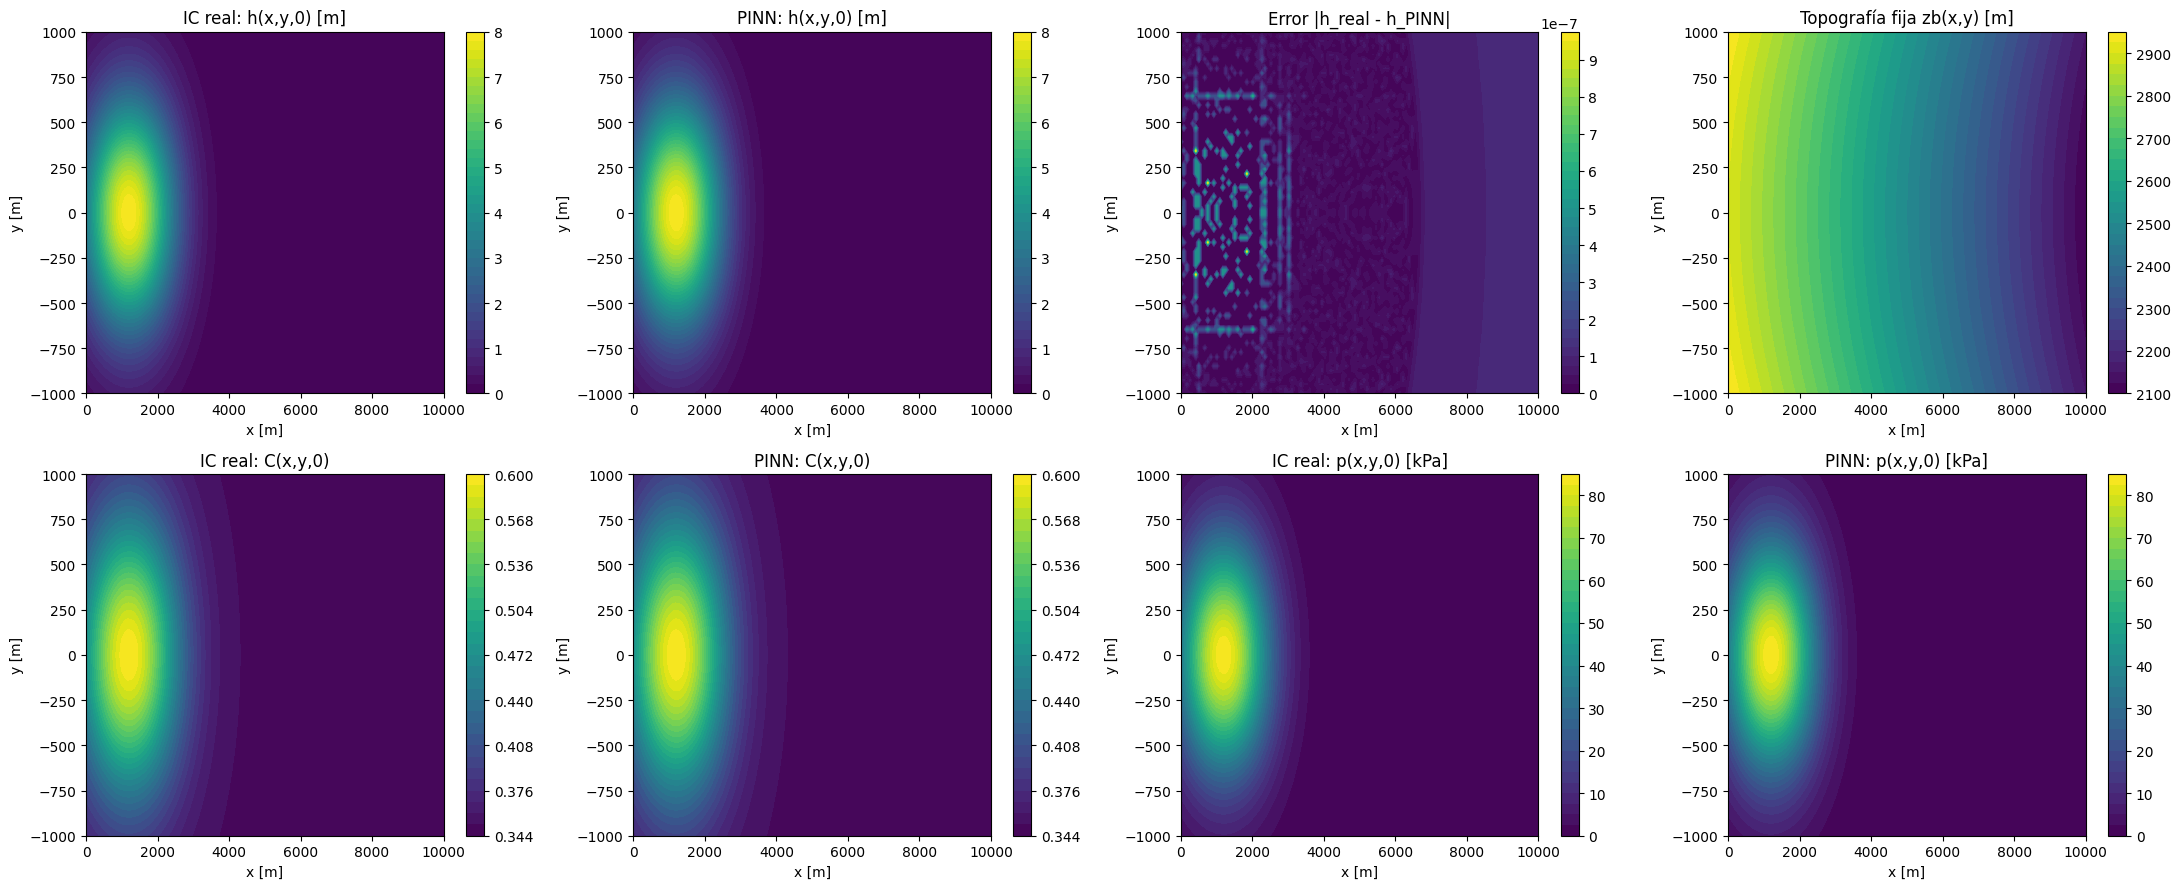

In [17]:
# ============================================================
# 11) VERIFICACIÓN DE CONDICIÓN INICIAL
# ============================================================
nx, ny = 120, 80
xg = np.linspace(x_min, x_max, nx).astype(np.float32)
yg = np.linspace(y_min, y_max, ny).astype(np.float32)
X, Y = np.meshgrid(xg, yg, indexing='xy')

Xf = X.reshape(-1, 1)
Yf = Y.reshape(-1, 1)
T0 = np.zeros_like(Xf, dtype=np.float32)

h_pred0, u_pred0, v_pred0, C_pred0, p_pred0 = predict_fields(
    tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(T0))

h0_map_pred = h_pred0.numpy().reshape(ny, nx)
C0_map_pred = C_pred0.numpy().reshape(ny, nx)
p0_map_pred = p_pred0.numpy().reshape(ny, nx)
zb_map = zb0_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

h0_map_true = ic_h_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
C0_map_true = ic_C_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
p0_map_true = ic_p_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

print("Error máximo de la IC (debe ser ~0 por el ansatz duro):")
print(f"  |h_real - h_PINN|_inf = {np.abs(h0_map_true - h0_map_pred).max():.3e} m")
print(f"  |C_real - C_PINN|_inf = {np.abs(C0_map_true - C0_map_pred).max():.3e}")
print(f"  |p_real - p_PINN|_inf = {np.abs(p0_map_true - p0_map_pred).max():.3e} Pa")

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
panels = [
    (h0_map_true, "IC real: h(x,y,0) [m]"),
    (h0_map_pred, "PINN: h(x,y,0) [m]"),
    (np.abs(h0_map_true - h0_map_pred), "Error |h_real - h_PINN|"),
    (zb_map, "Topografía fija zb(x,y) [m]"),
    (C0_map_true, "IC real: C(x,y,0)"),
    (C0_map_pred, "PINN: C(x,y,0)"),
    (p0_map_true / 1e3, "IC real: p(x,y,0) [kPa]"),
    (p0_map_pred / 1e3, "PINN: p(x,y,0) [kPa]"),
]
for ax, (Z, title) in zip(axes.ravel(), panels):
    cs = ax.contourf(X, Y, Z, levels=40)
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    plt.colorbar(cs, ax=ax)
plt.tight_layout()
plt.show()


  t [s]   x_centroide [m]   |u|_max [m/s]  lambda medio  masa/masa(0)
    0.0            1351.2            0.00         0.600        1.0000
   60.0            1456.1            1.59         0.062        1.0344
  120.0            1440.0            1.62         0.044        1.0323
  180.0            1446.6            1.59         0.036        1.0499
  240.0            1459.0            1.57         0.031        1.0697
  300.0            1471.1            1.55         0.027        1.0853
  360.0            1481.4            1.54         0.025        1.0955
  420.0            1489.5            1.52         0.023        1.1010
  480.0            1496.0            1.51         0.022        1.1029
  540.0            1501.1            1.50         0.021        1.1027
  600.0            1505.4            1.50         0.021        1.1015
  660.0            1509.1            1.49         0.020        1.1002
  720.0            1512.4            1.48         0.020        1.0994
  780.0            1

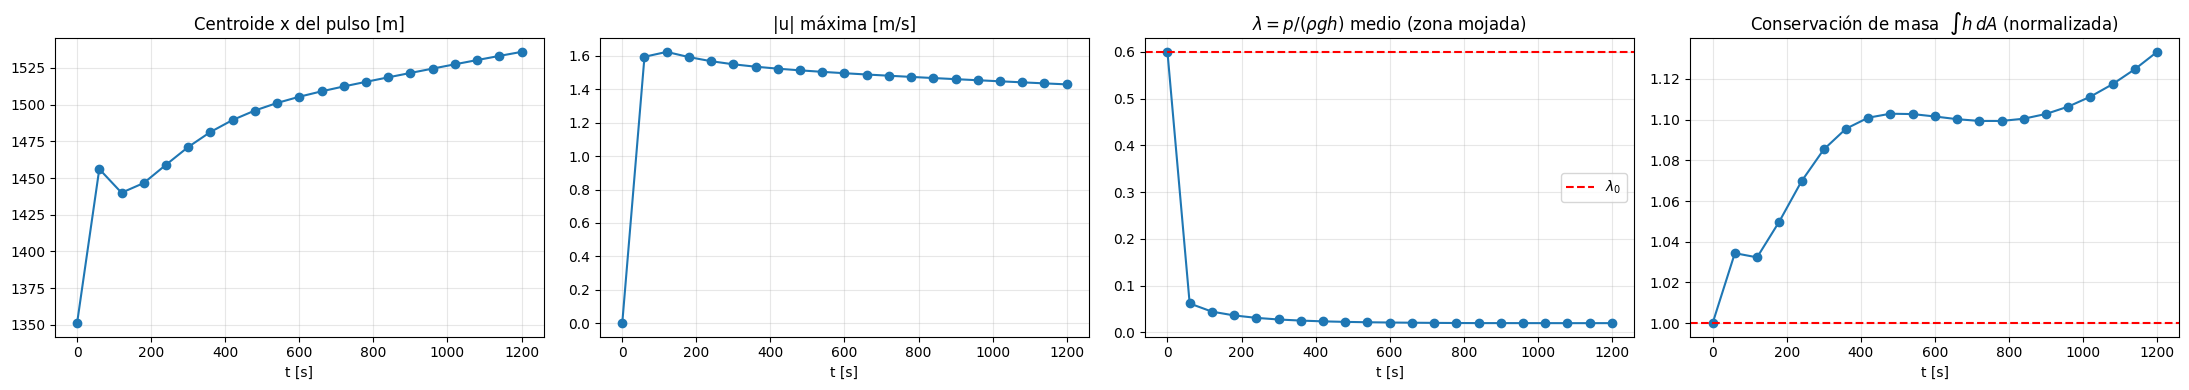

In [18]:
# ============================================================
# 12) DIAGNÓSTICO: ¿SE MOVIÓ EL LAHAR?   (la prueba de los puntos 1 y 2)
# ============================================================
t_check = np.linspace(0.0, Tmax, 21)
cent, vmax_l, lam_c, mass = [], [], [], []
cell_area = (xg[1] - xg[0]) * (yg[1] - yg[0])

for tv in t_check:
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))
    hh = hp.numpy().ravel(); uu = up.numpy().ravel(); vv = vp.numpy().ravel()
    pp_ = pp.numpy().ravel()
    w = np.maximum(hh, 0.0)
    cent.append(float((Xf.ravel() * w).sum() / max(w.sum(), 1e-12)))   # centroide ponderado por h
    vmax_l.append(float(np.sqrt(uu**2 + vv**2).max()))
    wet = hh > 0.1
    lam_c.append(float((pp_[wet] / (rho_m * g * hh[wet])).mean()) if wet.any() else np.nan)
    mass.append(float(w.sum() * cell_area))

print(f"{'t [s]':>7} {'x_centroide [m]':>17} {'|u|_max [m/s]':>15} "
      f"{'lambda medio':>13} {'masa/masa(0)':>13}")
for k, tv in enumerate(t_check):
    print(f"{tv:7.1f} {cent[k]:17.1f} {vmax_l[k]:15.2f} {lam_c[k]:13.3f} "
          f"{mass[k]/mass[0]:13.4f}")

desplazamiento = cent[-1] - cent[0]
print(f"\n>>> Desplazamiento del centroide en {Tmax:.0f} s: {desplazamiento:+.1f} m")
print(f">>> Velocidad media implícita: {desplazamiento/Tmax:+.2f} m/s")
print(f">>> Deriva de masa (debe ser ~1.0000, S_h=0): {mass[-1]/mass[0]:.4f}")
if desplazamiento < 50.0:
    print("\n*** EL FLUJO SIGUE BLOQUEADO. Revisa el gate y sube lambda_0/chi_p. ***")
else:
    print("\n*** EL LAHAR SE MUEVE. Puntos 1 y 2 cumplidos. ***")

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
axes[0].plot(t_check, cent, 'o-'); axes[0].set_title("Centroide x del pulso [m]")
axes[1].plot(t_check, vmax_l, 'o-'); axes[1].set_title("|u| máxima [m/s]")
axes[2].plot(t_check, lam_c, 'o-'); axes[2].set_title(r"$\lambda = p/(\rho g h)$ medio (zona mojada)")
axes[2].axhline(lambda_0, ls='--', c='r', label=r'$\lambda_0$'); axes[2].legend()
axes[3].plot(t_check, np.array(mass)/mass[0], 'o-'); axes[3].axhline(1.0, ls='--', c='r')
axes[3].set_title("Conservación de masa  " + r"$\int h\,dA$ (normalizada)")
for a in axes: a.set_xlabel("t [s]"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [19]:
# ============================================================
# 13) ANIMACIÓN: h, |u|, C, lambda
# ============================================================
import matplotlib.animation as animation
from IPython.display import HTML

frontera = "Neumann"
etiqueta = f"MKVII_chi{chi_p:.2f}_lam0{lambda_0:.2f}_topo{TOPO_SCENARIO}"
num_frames = 60
t_values = np.linspace(0.0, Tmax, num_frames)

# Niveles FIJOS: contourf con levels=<int> recalcula los niveles frame a frame
# a partir del rango de los datos e ignora vmin/vmax, lo que hacía que la
# escala de color cambiara en cada cuadro y la animación fuese engañosa.
lv_h   = np.linspace(0.0, 8.0, 41)
lv_u   = np.linspace(0.0, 20.0, 41)
lv_C   = np.linspace(0.2, 0.70, 41)
lv_lam = np.linspace(0.0, 1.0, 41)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f"Lahar MK VII — {Tmax:.0f} s — BC: {frontera} — "
             rf"$\chi_p$={chi_p}, $\lambda_0$={lambda_0}, $\xi$={xi_voellmy:.0f}")

def update(frame):
    for a in axes.ravel(): a.clear()
    tv = t_values[frame]
    Tf = np.full_like(Xf, tv, dtype=np.float32)
    hp, up, vp, Cp, pp = predict_fields(
        tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf), tf.convert_to_tensor(Tf))

    h_map = hp.numpy().reshape(ny, nx)
    U_map = np.sqrt(up.numpy()**2 + vp.numpy()**2).reshape(ny, nx)
    C_map = Cp.numpy().reshape(ny, nx)
    lam_map = (pp.numpy() / (rho_m * g * np.maximum(hp.numpy(), 1e-6))).reshape(ny, nx)

    dry = h_map < 0.05                      # máscara por h, NO por C
    U_m   = np.ma.masked_where(dry, U_map)
    C_m   = np.ma.masked_where(dry, C_map)
    lam_m = np.ma.masked_where(dry, lam_map)

    for a in axes.ravel(): a.set_facecolor('lightgrey')

    axes[0, 0].contourf(X, Y, h_map, levels=lv_h, cmap='viridis', extend='max')
    axes[0, 0].set_title(f"Espesor h  t={tv:.0f}s  [m]")
    axes[0, 1].contourf(X, Y, U_m, levels=lv_u, cmap='magma', extend='max')
    axes[0, 1].set_title(f"Velocidad |u|  t={tv:.0f}s  [m/s]")
    axes[1, 0].contourf(X, Y, C_m, levels=lv_C, cmap='plasma', extend='both')
    axes[1, 0].set_title(f"Concentración C  t={tv:.0f}s")
    axes[1, 1].contourf(X, Y, lam_m, levels=lv_lam, cmap='cividis', extend='both')
    axes[1, 1].set_title(rf"Razón de poros $\lambda=p/(\rho g h)$  t={tv:.0f}s")
    for a in axes.ravel():
        a.set_xlabel("x [m]"); a.set_ylabel("y [m]")

print("Generando animación, por favor espera...")
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100)
aniname = f"Prediccion {etiqueta}.gif"
ani.save(aniname, writer='pillow', fps=10)
print(f"GIF guardado como '{aniname}'")
plt.close()
display(HTML(ani.to_jshtml()))


Generando animación, por favor espera...
GIF guardado como 'Prediccion MKVII_chi0.80_lam00.60_topo2.gif'


# Por hacer (actualizado)

## Hecho en MK VII
- [x] **Punto 1** — desbloqueo friccional: `chi_p` 0.35→0.80, `p_ref` 1e4→1e3, gate de verificación previo al entrenamiento.
- [x] **Punto 2** — `p` como 5ª salida de la red con EDO de relajación $Dp/Dt=(p_{eq}-p)/\tau_p$ y ansatz duro $\lambda(0)=\lambda_0$.
- [x] Término turbulento de Voellmy (velocidad terminal finita).
- [x] Topografía tipo Villarrica disponible (`TOPO_SCENARIO = 4`).

## Siguiente (puntos 3–5 del análisis)
- [ ] **Punto 3** — `kappa_C = 0` y eliminar `loss_C_flux` por completo.
- [ ] **Punto 4** — resolver $m = hC$ en vez de $C$.
- [ ] **Punto 5** — quitar `h = 0` en las paredes; poner $v = 0$ (deslizamiento libre).
- [ ] Renombrar / rehacer el notebook "Dirichlet" (hoy impone Neumann, igual que este).
- [ ] Quitar `LossScaleOptimizer`, pasar a `global_clipnorm`, eliminar los $\lambda$ globales.
- [ ] Benchmarks de verificación: dam-break de Ritter + cuenco de Thacker.
- [ ] Adam → L-BFGS.
- [ ] Agregar la DEM real y comparar con el mapa del evento de marzo 2015.
